# Reading Dataset

In [69]:
import pandas as pd
df_review = pd.read_csv('IMDB Dataset.csv')

## Main purpose to take a small sample of whole data to maximize efficieny

In [70]:
# 9000 positive
df_positive = df_review[df_review['sentiment'] == 'positive'][0:9000]
#1000 negative
df_negative = df_review[df_review['sentiment'] == 'negative'][0:1000]
# my code
# select 10000 rows to make the processing faster and get the data imbalace

#9000 positive
# df_positive = df_review[df_review['sentiment'] == 'positive'].iloc[0:9000]

# #1000 negative
# df_negative = df_review[df_review['sentiment'] == 'negative'].iloc[0:1000]
# df_concat = pd.concat([df_positive,df_negative],axis = 0)
# df_concat.sample(frac = 1) #frac and 10000 only at one time
# df_concat = df_concat.reset_index(drop=True)
# df_concat


In [71]:
#concat the data
df_review_imdb = pd.concat([df_positive,df_negative])
df_review_imdb = df_review_imdb.sample(frac = 1)

## Data Imbalance(unequal distribution of data in one sample and the another)

In [72]:
df_review_imdb.value_counts('sentiment')

sentiment
positive    9000
negative    1000
Name: count, dtype: int64

In [73]:
#we have the data imbalance in out dataset because there are 9 times more positive review then negative
#which will affect the data training and prediction 

## 2 Dealing with Imbalanced classes

<Axes: xlabel='sentiment'>

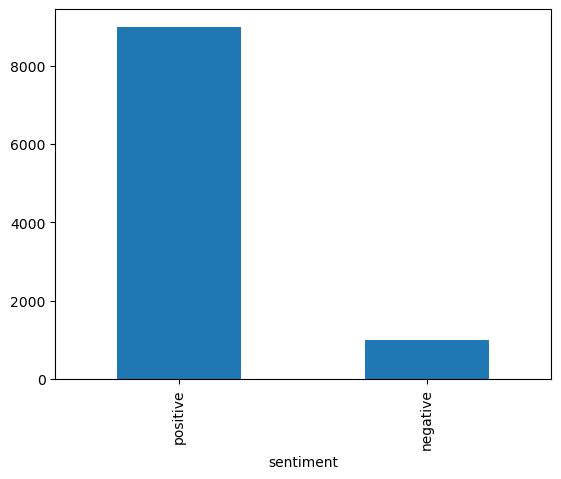

In [74]:
#make a barplot to show how data is distributed
df_review_imdb.value_counts('sentiment').plot(kind = 'bar')

## 2.1 Balancing data with .sample()

In [75]:
length_negative = len(df_review_imdb[df_review_imdb['sentiment'] == 'negative'])

In [76]:
length_negative

1000

In [77]:
df_reviews_positive = df_review_imdb[df_review_imdb['sentiment'] == 'positive'].sample(n = length_negative)

In [78]:
df_reviews_negative = df_review_imdb[df_review_imdb['sentiment'] == 'negative']

In [79]:
df_reviews_bal = pd.concat([df_reviews_positive, df_reviews_negative])

In [80]:
df_reviews_bal.value_counts('sentiment')

sentiment
negative    1000
positive    1000
Name: count, dtype: int64

In [81]:
df_reviews_bal.reset_index(drop = True, inplace = True) #drop = true reset the whole index
#drop = false reset it and also keeps old index as a new column adjacet to new index

In [82]:
df_reviews_bal

,review,sentiment
0,"I really love this show, it's like reading a b...",positive
1,"After the glories of The Snare, it was unlikel...",positive
2,After seeing this film I feel like I know just...,positive
3,I know that there are some purists out there w...,positive
4,For anyone who liked the series this movie wil...,positive
...,...,...
1995,"When this was released, I thought this was one...",negative
1996,This show makes absolutely no sense. Every wee...,negative
1997,"At the beginning of the film, you might double...",negative
1998,-SPOILES- Lame south of the border adventure m...,negative


## 2.2 Balancing data with RandomUnderSampler

In [83]:
from imblearn.under_sampling import RandomUnderSampler
# create a object or instance of RandomUnderSampler
rus = RandomUnderSampler(random_state = 0) # a random state will give fixed random sample always everytime

# rus.fit_resample(x,y) # -> x is the data which is to be sampled(should be dataframe)
# and y are labels for each sample in x

len(df_review_imdb)
df_review_bal, df_review_bal['sentiment'] = rus.fit_resample(df_review_imdb[['review']], df_review_imdb['sentiment']) #10000 reviews and sentiment here
# The "Fit" Part:The method first looks at your target labels ($y$) and counts the occurrences of each class.
# It calculates the distribution to identify which class is the "Majority" and which is the "Minority." It 
# then determines exactly how many samples need to be removed (under-sampling) or added (over-sampling) to
# reach the desired balance.The "Resample" Part:Once the plan is created, it applies the transformation. 
# It creates a new dataset by either deleting rows from the majority or synthesizing/duplicating rows for
# the minority.

df_review_bal, df_review_bal['sentiment'] #-> assignint the data frame and addind a new column sentiment 

(                                                  review sentiment
 709    Watch the Original with the same title from 19...  negative
 1712   i completely agree with jamrom4.. this was the...  negative
 266    Sometimes you just have to have patients when ...  negative
 358    This movie features Charlie Spradling dancing ...  negative
 1731   I picked up this movie with the intention of g...  negative
 ...                                                  ...       ...
 9373   The film is exceptional in it's gay iconograph...  positive
 12529  In this installment of the series, Edmund Blac...  positive
 16732  The movie was very good when it came out, I at...  positive
 6373   I first saw this movie when I was about 12 yea...  positive
 2933   A Scanner Darkly, Minority Report, Blade Runne...  positive
 
 [2000 rows x 2 columns],
 709      negative
 1712     negative
 266      negative
 358      negative
 1731     negative
            ...   
 9373     positive
 12529    positive
 167

In [84]:
df_review_bal.value_counts('sentiment')

sentiment
negative    1000
positive    1000
Name: count, dtype: int64

## Oversampling
#### for the imblearn.oversampling import RandomOverSampler
#### all the steps afer this are same

In [85]:
len(df_positive)
len(df_negative)

1000

In [86]:
#oversampling by sample - > replace should be true when taking sample larger than itself has
len_positive_oversample = len(df_positive)
df_negative_oversample = df_negative.sample(n = len_positive_oversample, replace = True)
df_positive_oversample = df_positive

df_oversample_balance = pd.concat([df_negative_oversample , df_positive_oversample])
df_oversample_balance.value_counts('sentiment')

sentiment
negative    9000
positive    9000
Name: count, dtype: int64

In [87]:
#oversampling by Oversample imblearn
from imblearn.over_sampling import RandomOverSampler
rust = RandomOverSampler(random_state = 0)
df_oversample_balanced, df_oversample_balanced['sentiment'] = rust.fit_resample(df_review_imdb[['review']], df_review_imdb['sentiment'])
df_oversample_balanced



# a better way
x_resampled, y_resampled = r.fit_resample(df_review_imdb[['review']], df_review_imdb['sentiment'])

# 3. If you want them back in a single DataFrame for viewing:
df_oversample_balanced = x_resampled.copy()
df_oversample_balanced['sentiment'] = y_resampled

#in .fit_resample(x,y)
# x should be dataframe and y should be series

NameError: name 'r' is not defined

## Split Data into train and test

In [88]:
# df_review_bal this balanced dataset is used here which was undersampled by randomundersampler
#import train test split
from sklearn.model_selection import train_test_split
train,test = train_test_split(df_review_bal,test_size = 0.33,
                              random_state = 42)

In [89]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [90]:
train_y.value_counts()
type(train_x)

pandas.core.series.Series

# Text Representation (Bag of Words)

### 4.1 Count Vectorizer

### fit transform will do this
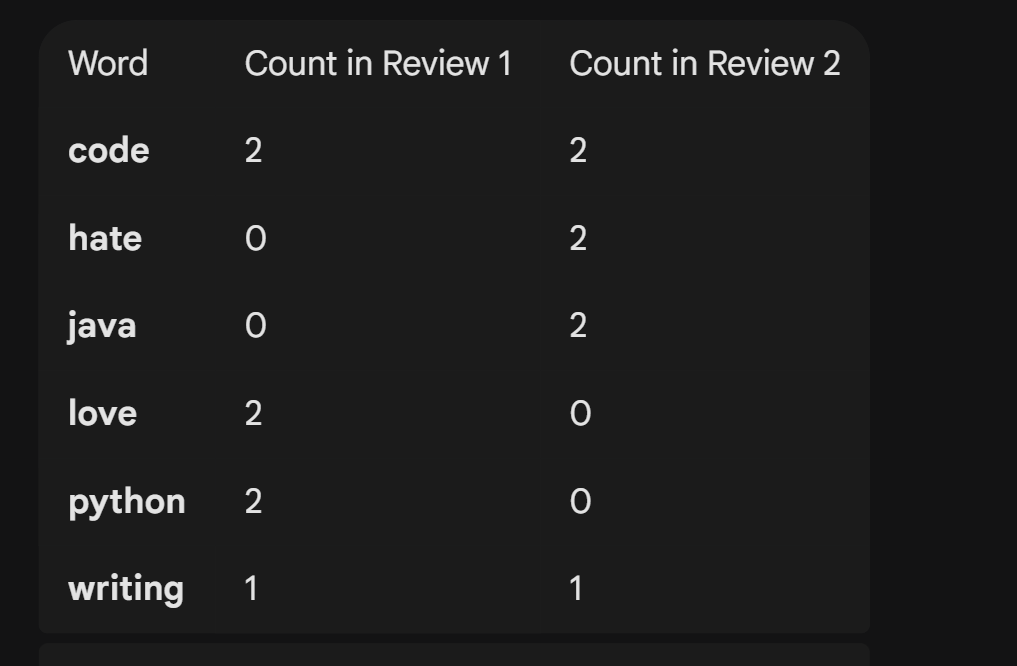

In [91]:
from sklearn.feature_extraction.text import CountVectorizer
text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]
df = pd.DataFrame({ 'review' : ['review1', 'review2'], 
                   'text' : text
                  })
cv = CountVectorizer(stop_words  = 'english')  # helps to filter out stop words like, in, I etc
cv_matrix = cv.fit_transform(df['text'])  #series is given of text not the text list here
#fit_transform accepts an iterator whether it is list or pandas series, in series it iterate each row

# fit: The model scans all the text in df['text']. It ignores the 'english' stop words (like "I", "in"),
# identifies every unique remaining word (the "tokens"), and builds a dictionary (vocabulary).

# transform: It converts those two rows of text into a Sparse Matrix of numbers. Each number represents
# how many times a specific word from the vocabulary appeared in that row.
cv_matrix.toarray() # here i can see when matrix converted to array it has all unique word columns occurence value
# df['review']

array([[2, 0, 0, 2, 2, 1],
       [2, 2, 2, 0, 0, 1]])

In [92]:
# If you want to actually "see" the matrix you just created, fit_transform
# returns a sparse matrix which isn't very readable. You can convert it to
# an array or a DataFrame like this:
# See the unique words it found
print(cv.get_feature_names_out())

# Convert to a readable DataFrame
df_dtm = pd.DataFrame(cv_matrix.toarray(), index = df['review'].values,
                      columns = cv.get_feature_names_out()) #features became columns here, index and matrix is the value
df_dtm

['code' 'hate' 'java' 'love' 'python' 'writing']


,code,hate,java,love,python,writing
review1,2,0,0,2,2,1
review2,2,2,2,0,0,1


In [93]:
df  #only the text column/series is given to the fit_transform in count_vectorizer

,review,text
0,review1,I love writing code in Python. I love Python code
1,review2,I hate writing code in Java. I hate Java code


##  4.2 TF-DF (using small dataframe for explanation)

In [259]:
# important added after - tfidf is the standardizer here so for taking user input we need this model file saved.
from sklearn.feature_extraction.text import TfidfVectorizer
text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]
df = pd.DataFrame({ 'review' : ['review1', 'review2'], 
                   'text' : text
                  })
Tfidf = TfidfVectorizer(stop_words = 'english', norm = None) 
Tfidf_matrix = Tfidf.fit_transform(df['text']) #series given here

In [263]:
print(f"Vocabulary Size: {len(Tfidf.vocabulary_)}")
#don't pickle here

Vocabulary Size: 6


In [264]:
df_tfidf = pd.DataFrame(Tfidf_matrix.toarray(), index = df['review'].values,
                        columns = Tfidf.get_feature_names_out())
print(df_tfidf)

Tfidf_matrix.toarray() # only store the 2d array each element is array which
# are values for first review then to last
Tfidf.get_feature_names_out() # tfidf has the column name not the matrix which is in Tfidf_matrix

         code     hate     java     love   python  writing
review1   2.0  0.00000  0.00000  2.81093  2.81093      1.0
review2   2.0  2.81093  2.81093  0.00000  0.00000      1.0


array(['code', 'hate', 'java', 'love', 'python', 'writing'], dtype=object)

# Turning our text data into numerical vectors
# using dataset

In [265]:
#using the random oversampler data
df_review_bal
#review of train set
train_x

#previously we gave a series of two rows(review1 and review1) in which sentence were there
#now a series of 1340 rows(reviews) each rows has a review sentence , it's the same but at large scale

1462     Here's one you can watch with a straight face,...
1035     OK, how's this for original- this mean, rich o...
18004    La Teta i la Luna (The Breast and the Moon) de...
1774     This is a truly awful "B" movie. It is witless...
4792     I guess this movie will only work on people wh...
                               ...                        
979      This is one of the finest films to come out of...
2451     I have to agree with the previous author's com...
970      *Criticism does mention spoilers*<br /><br />I...
15969    Betty Sizemore (Renee Zellweger) lives her lif...
17375    That was definitely the case with Angels in th...
Name: review, Length: 1340, dtype: object

In [266]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words = 'english')
train_x_vector = tfidf.fit_transform(train_x)
train_x_vector # sparse matrix - 2d array 
tfidf.get_feature_names_out()

array(['00', '000', '007', ..., 'être', 'ísnt', 'île'], dtype=object)

In [268]:
print(f"Vocabulary Size: {len(tfidf.vocabulary_)}")

Vocabulary Size: 20428


In [228]:
# import pickle
# pickle.dump(Tfidf, open('tfidf_fitted.pkl', 'wb'))

In [229]:
#  both give same answers
df_tf = pd.DataFrame(train_x_vector.toarray(),
                        index = train_x.index,
                        columns = tfidf.get_feature_names_out())
df_tf

pd.DataFrame.sparse.from_spmatrix(train_x_vector,
                                  index = train_x.index,
                                  columns = tfidf.get_feature_names_out())

,00,000,007,00am,01pm,02,03,05,06th,08,...,zorro,zosch,zu,zues,zzzzzzzzzzzzzzzzzz,æon,élan,être,ísnt,île
1462,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1035,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1774,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4792,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,0,0,0,0,0,0,0,0,0,0,...,0,0,0.086688,0,0,0,0,0,0,0
2451,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
970,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15969,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [230]:
test_x_vector = tfidf.transform(test_x)
# we only transform the test_x cuz tfidf already has the best parameters cuz it has fit_transformed 
# the train_x and i think the values are stored in the tfidf itself

In [269]:
import pickle
pickle.dump(tfidf, open('tfidf_fitted.pkl', 'wb'))

In [271]:
print(f"Vocabulary Size: {len(tfidf.vocabulary_)}")

Vocabulary Size: 20428


In [272]:
#  both give same answers
df_tf_test = pd.DataFrame(test_x_vector.toarray(),
                        index = test_x.index,
                        columns = tfidf.get_feature_names_out())

In [273]:
df_tf_test

,00,000,007,00am,01pm,02,03,05,06th,08,...,zorro,zosch,zu,zues,zzzzzzzzzzzzzzzzzz,æon,élan,être,ísnt,île
10977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8426,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1820,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6928,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4409,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1030,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#  Supervised Learning algorithm 
# 4 Classificaton algorithms

## SVM Support vector machines

In [274]:
from sklearn.svm import SVC
svc = SVC(kernel = 'linear')
svc.fit(train_x_vector,train_y) # we fit it with numerical vector or sparx matrix

SVC(kernel='linear')

In [275]:
#predecting a single test by converting it into vector(numerical data)
print(svc.predict(tfidf.transform(['fantastic']))) # for predicting also, we fit it with numerical vector or sparx mat

['positive']


In [276]:
#predicting the whole test data already in vector form by tfidf
#- later confusion matrix take this data and gives the matrix
svc.predict(test_x_vector)

array(['negative', 'negative', 'positive', 'negative', 'positive',
       'positive', 'negative', 'positive', 'negative', 'negative',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'negative', 'negative', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'negative', 'negative', 'negative',
       'negative', 'negative', 'negative', 'positive', 'negative',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'positive', 'positive', 'negative', 'negative', 'positive',
       'negative', 'negative', 'negative', 'negative', 'positive',
       'positive', 'negative', 'positive', 'negative', 'negative',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'positive', 'negative', 'negative', 'positive', 'positive',
       'negative', 'negative', 'negative', 'negative', 'positive',
       'positive', 'positive', 'negative', 'positive', 'negati

# Decision Tree

In [277]:
from sklearn.tree import DecisionTreeClassifier
dec_tree = DecisionTreeClassifier()
dec_tree.fit(train_x_vector, train_y) #train_x_vector -> numerical data

DecisionTreeClassifier()

In [278]:
dec_tree.get_depth() #to find the tree depth

48

In [279]:
dec_tree.predict(tfidf.transform(['good movie']))

array(['positive'], dtype=object)

In [280]:
dec_tree.predict(test_x_vector)

array(['positive', 'negative', 'positive', 'negative', 'negative',
       'positive', 'negative', 'negative', 'negative', 'negative',
       'negative', 'positive', 'positive', 'negative', 'negative',
       'negative', 'negative', 'negative', 'positive', 'negative',
       'positive', 'negative', 'positive', 'positive', 'negative',
       'positive', 'negative', 'positive', 'positive', 'negative',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'negative', 'positive', 'positive', 'negative', 'positive',
       'positive', 'negative', 'negative', 'negative', 'negative',
       'negative', 'negative', 'negative', 'positive', 'positive',
       'positive', 'positive', 'negative', 'negative', 'negative',
       'positive', 'positive', 'positive', 'positive', 'positive',
       'negative', 'positive', 'positive', 'negative', 'positive',
       'positive', 'positive', 'positive', 'negative', 'positive',
       'positive', 'positive', 'negative', 'negative', 'positi

# 6.3 Naive Bayes

In [281]:
#Gaussian NB
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(train_x_vector.toarray(), train_y) # gnb takes array of sparx matrix not the matrix itself

GaussianNB()

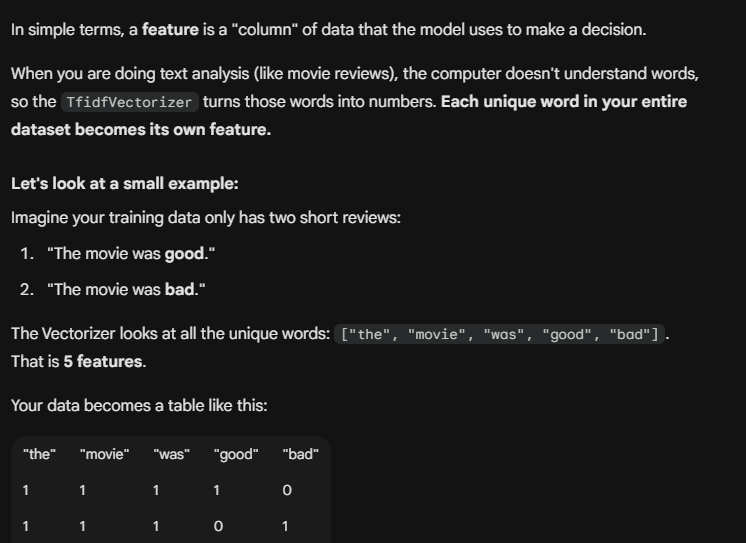

In [282]:
gnb.predict(tfidf.transform(['a very good movie']).toarray())

array(['negative'], dtype='<U8')

In [283]:
gnb.predict(test_x_vector.toarray())

array(['negative', 'negative', 'positive', 'positive', 'positive',
       'positive', 'negative', 'negative', 'positive', 'positive',
       'positive', 'positive', 'negative', 'negative', 'negative',
       'positive', 'positive', 'negative', 'positive', 'positive',
       'negative', 'positive', 'negative', 'positive', 'positive',
       'negative', 'negative', 'negative', 'negative', 'negative',
       'positive', 'negative', 'negative', 'positive', 'positive',
       'negative', 'negative', 'positive', 'negative', 'negative',
       'positive', 'negative', 'negative', 'positive', 'negative',
       'negative', 'negative', 'negative', 'negative', 'positive',
       'positive', 'positive', 'negative', 'negative', 'negative',
       'positive', 'negative', 'positive', 'positive', 'negative',
       'negative', 'positive', 'negative', 'positive', 'positive',
       'negative', 'positive', 'negative', 'positive', 'negative',
       'negative', 'positive', 'positive', 'positive', 'negati

In [284]:
#Multinomial NB
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(train_x_vector, train_y) #don't require the vector data to convert to array
#multinomial accepts sparx matrix good for discrete value and gaussian for continuous values

MultinomialNB()

In [285]:
mnb.predict(tfidf.transform(['a very good movie']).toarray())

array(['negative'], dtype='<U8')

In [286]:
mnb.predict(test_x_vector.toarray())

array(['negative', 'negative', 'positive', 'positive', 'positive',
       'positive', 'negative', 'negative', 'negative', 'negative',
       'negative', 'positive', 'positive', 'negative', 'negative',
       'negative', 'negative', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'positive', 'positive',
       'negative', 'positive', 'negative', 'negative', 'negative',
       'negative', 'negative', 'negative', 'positive', 'negative',
       'negative', 'negative', 'positive', 'positive', 'negative',
       'positive', 'negative', 'negative', 'negative', 'positive',
       'negative', 'negative', 'negative', 'negative', 'positive',
       'positive', 'negative', 'positive', 'negative', 'negative',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'positive', 'negative', 'negative', 'positive', 'positive',
       'negative', 'negative', 'negative', 'negative', 'positive',
       'negative', 'negative', 'negative', 'negative', 'negati

# Logistic Regressoin
### binary classification (either 0 or 1, yes or no, positive or negative, one case or the other)

In [287]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(train_x_vector, train_y)  #takes vector

LogisticRegression()

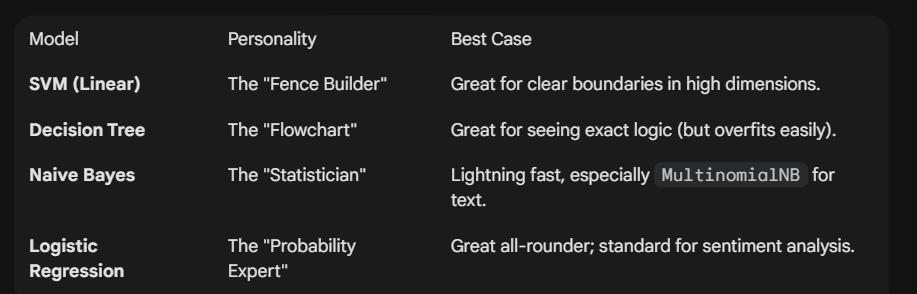

In [288]:
log_reg.predict(tfidf.transform(['a good movie']))
log_reg.predict_proba(tfidf.transform(['a good movie']))  #gives yer prob then no prob
#In your example: For "A very bad movie," you should see a very high number on the left
# (e.g., 0.98) and a very low number on the right (e.g., 0.02). This means the model is
# 95% sure the movie is bad.

array([[0.4224738, 0.5775262]])

In [289]:
log_reg.predict(test_x_vector) #for output
log_reg.predict_proba(test_x_vector) # for probability

array([[0.52670695, 0.47329305],
       [0.57861295, 0.42138705],
       [0.34793996, 0.65206004],
       ...,
       [0.36531929, 0.63468071],
       [0.47152276, 0.52847724],
       [0.51570049, 0.48429951]])

# 7 Model Evaluation

## 7.1 Confusion Matrix

In [290]:
len(test_x_vector.toarray())
# length same as test_x

660

### Confusion matrix for Support vector machines

In [291]:
from sklearn.metrics import confusion_matrix
confusion_matrix(test_y,                 #actual labels - in series see below
                 svc.predict(test_x_vector),  #predictions based on test data see below these
                 labels = ['positive', 'negative']) # labels we will get confusion matrix in this order

# 283+52+278+47 = 660

array([[270,  65],
       [ 54, 271]])

In [159]:
svc.predict(test_x_vector)[:5] #-> array with predicted output of all rows
# test_y -> actual values of all rows

array(['negative', 'negative', 'positive', 'negative', 'positive'],
      dtype=object)

### Confusion matrix for Decision Tree

In [160]:
from sklearn.metrics import confusion_matrix
confusion_matrix(test_y,                 #actual labels - in series see below
                 dec_tree.predict(test_x_vector),  #predictions based on test data see below these
                 labels = ['positive', 'negative']) # labels we will get confusion matrix in this order

# 283+52+278+47 = 660

array([[232, 103],
       [ 95, 230]])

### Confusion matrix for Naive Bayes

In [161]:
from sklearn.metrics import confusion_matrix
confusion_matrix(test_y,                 #actual labels - in series see below
                 gnb.predict(test_x_vector.toarray()),  #predictions based on test data see below these
                 labels = ['positive', 'negative']) # labels we will get confusion matrix in this order

# 283+52+278+47 = 660

array([[221, 114],
       [114, 211]])

In [162]:
from sklearn.metrics import confusion_matrix
confusion_matrix(test_y,                 #actual labels - in series see below
                 mnb.predict(test_x_vector),  #predictions based on test data see below these
                 labels = ['positive', 'negative']) # labels we will get confusion matrix in this order

# 283+52+278+47 = 660

array([[233, 102],
       [ 26, 299]])

### Confusion matrix for Logistic Regression

In [163]:
from sklearn.metrics import confusion_matrix
confusion_matrix(test_y,                 #actual labels - in series see below
                 log_reg.predict(test_x_vector),  #predictions based on test data see below these
                 labels = ['positive', 'negative']) # labels we will get confusion matrix in this order

# 283+52+278+47 = 660

array([[278,  57],
       [ 60, 265]])

## 7.2 Mean Accuracy

In [164]:
#calculate accuracy of of model
# it is calculated by ratio of ( TP + TN ) and ( TP + FP + TN + FN)

# but we can calcuate by model.score(test_vector_x, test_y)  -> x = numerical test data, y = lables of each x

print(svc.score(test_x_vector, test_y))
print(dec_tree.score(test_x_vector, test_y))
print(gnb.score(test_x_vector.toarray(), test_y))
print(mnb.score(test_x_vector, test_y))
print(log_reg.score(test_x_vector, test_y))

0.8196969696969697
0.7
0.6545454545454545
0.806060606060606
0.8227272727272728


# 7.3 F1 Score

### Precision Score and Recall


In [165]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
precision_score(test_y,
         svc.predict(test_x_vector),
         labels =  ['negative', 'positive'],
        average = None)

array([0.80654762, 0.83333333])

In [166]:
recall_score(test_y,
         svc.predict(test_x_vector),
         labels =  ['negative', 'positive'],
        average = None)

array([0.83384615, 0.80597015])

In [167]:
# f1 score is the weighted average of the precison and recall


from sklearn.metrics import f1_score
f1_score(test_y,
         svc.predict(test_x_vector),
         labels =  ['negative', 'positive'],
        average = None)

#the first one is for negative and the second value is for positive

array([0.81996974, 0.81942337])

In [168]:
# f1 score, precison and recall , model tuning + remaining chapter() after that done
# and practice the code

In [169]:
f1_score(test_y,
         gnb.predict(test_x_vector.toarray()),
         labels =  ['negative', 'positive'],
        average = None)

array([0.64923077, 0.65970149])

In [170]:
f1_score(test_y,
         mnb.predict(test_x_vector.toarray()),
         labels =  ['negative', 'positive'],
        average = None)

array([0.82369146, 0.78451178])

In [171]:
f1_score(test_y,
         dec_tree.predict(test_x_vector.toarray()),
         labels =  ['negative', 'positive'],
        average = None)

array([0.69908815, 0.70090634])

In [172]:
f1_score(test_y,
         log_reg.predict(test_x_vector.toarray()),
         labels =  ['negative', 'positive'],
        average = None)

array([0.81916538, 0.82615156])

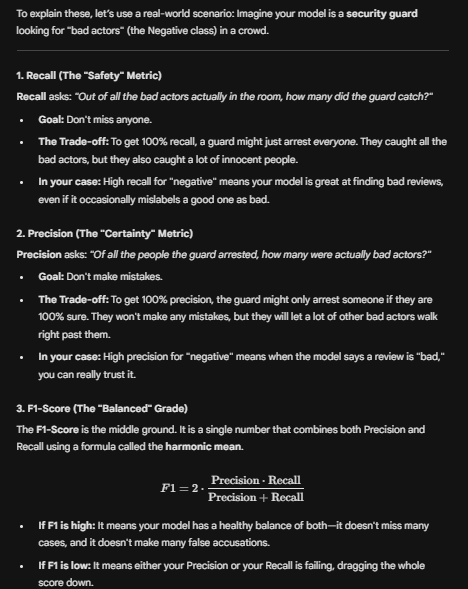

# 7.4 Classification Report
shows precision, recall and f1-score

In [173]:
from sklearn.metrics import classification_report
print(classification_report(test_y,
               svc.predict(test_x_vector),
               labels = ['positive', 'negative'])
     )

              precision    recall  f1-score   support

    positive       0.83      0.81      0.82       335
    negative       0.81      0.83      0.82       325

    accuracy                           0.82       660
   macro avg       0.82      0.82      0.82       660
weighted avg       0.82      0.82      0.82       660



## 8 Tuning the Model
### 8.1 GridSearchCV

In [174]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': [1,4,8,16,32], 'kernel':['linear', 'rbf']}
svc = SVC()
svc_grid = GridSearchCV(svc, parameters, cv=5)
svc_grid.fit(train_x_vector, train_y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 4, 8, 16, 32], 'kernel': ['linear', 'rbf']})

In [175]:
svc_grid.best_params_

{'C': 4, 'kernel': 'rbf'}

In [176]:
svc_grid.best_estimator_

SVC(C=4)

### Tfidf(standardizer has been dumped earlier in the cell)
### Pickling(saving) all the model files

In [293]:
import pickle
pickle.dump(svc, open('svc.pkl', 'wb'))
pickle.dump(dec_tree, open('dec_tree.pkl', 'wb'))
pickle.dump(gnb, open('gnb.pkl', 'wb'))
pickle.dump(mnb, open('mnb.pkl', 'wb'))
pickle.dump(log_reg, open('log_reg.pkl', 'wb'))

In [294]:
log_reg_model = pickle.load(open('log_reg.pkl', 'rb'))
tfidf_load = pickle.load(open('tfidf_fitted.pkl', 'rb'))

In [295]:
print(f"Vocabulary Size: {len(tfidf_load.vocabulary_)}")

Vocabulary Size: 20428


In [296]:
log_reg_model.predict(tfidf.transform(["this is the best movie i have ever watched"]))

array(['positive'], dtype=object)